STEP 1: Import required libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl
from skimage.filters import threshold_multiotsu  # For entropy-based automatic thresholding

STEP 2: Load the grayscale image

✅ Image loaded successfully from Google Drive.


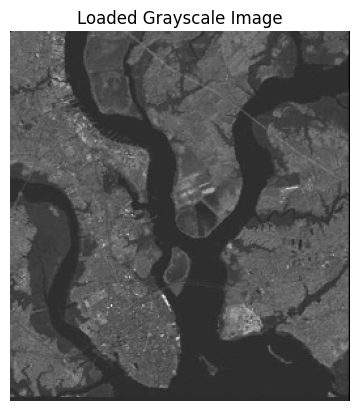

In [2]:
image_url = "https://drive.google.com/uc?export=download&id=11F2jKq_cUMbNo9-hEDr6WRag7kT7M3oN"


context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_np = np.asarray(bytearray(resp.read()), dtype=np.uint8)
gray = cv2.imdecode(image_np, cv2.IMREAD_GRAYSCALE)  # Grayscale read

if gray is None:
    raise Exception("❌ Image could not be loaded from URL.")
else:
    print("✅ Image loaded successfully from Google Drive.")

plt.imshow(gray, cmap='gray')
plt.title("Loaded Grayscale Image")
plt.axis('off')
plt.show()

Define Multilevel Threshold Intervals

    These intensity ranges are derived from histogram analysis

    Thresholds = [T1, T2] → creates 3 regions: [0,T1], [T1+1,T2], [T2+1,255]

STEP 3: Manual Thresholding

    ➤ Importance:
      - Segment image into different meaningful regions
      - Useful in medical, satellite, and document image processing

    ➤ Formula:
      For each pixel (x,y):
        If  0 ≤ I(x,y) ≤ T1      → Region 1
        If T1 < I(x,y) ≤ T2      → Region 2
        If T2 < I(x,y) ≤ 255     → Region 3

In [3]:
# Define thresholds manually (based on histogram observation)
T1_manual, T2_manual = 60, 119

# Create color segmented image using manual thresholds
segmented_manual = np.zeros((*gray.shape, 3), dtype=np.uint8)

# Assign colors: Blue (0-60), Green (61-119), Yellow (120-255)
segmented_manual[(gray >= 0) & (gray <= T1_manual)]     = [255, 0, 0]     # Blue
segmented_manual[(gray > T1_manual) & (gray <= T2_manual)] = [0, 255, 0]  # Green
segmented_manual[(gray > T2_manual) & (gray <= 255)]    = [255, 255, 0]   # Yellow

STEP 4: Automatic Multilevel Thresholding (Multi-Otsu)


    🔍 Importance:
    # Multi-Otsu thresholding is an extension of Otsu’s method that finds *multiple* optimal thresholds
    # that best separate the image histogram into distinct intensity classes (e.g., dark, medium, bright).
    # It maximizes the *inter-class variance* (between regions) while minimizing the *intra-class variance*
    # (within each region).

    This is useful in:
    # - Satellite image segmentation (land, water, urban)
    # - Medical imaging (tissue classification)
    # - Document processing (background vs ink)
    # - Industrial vision (defect localization)

    🧮 Formula:
    # Let there be `K` classes divided by `K−1` thresholds: t₁, t₂, ..., tₖ₋₁

    # The goal is to find the thresholds that maximize the **inter-class variance**:
    #     σ_b² = ∑_{i=1}^{K} ωᵢ * (μᵢ − μ_T)²
        # Where:
        # - ωᵢ = probability (weight) of class i
        # - μᵢ = mean intensity of class i
        # - μ_T = total mean intensity of the image

    # This is done by exhaustively searching combinations of thresholds that maximize σ_b².

In [4]:
# Multi-Otsu finds optimal thresholds to maximize inter-class variance
auto_thresholds = threshold_multiotsu(gray, classes=3)
T1_auto, T2_auto = auto_thresholds
print(f"🔍 Auto Thresholds (Multi-Otsu): T1 = {T1_auto}, T2 = {T2_auto}")

# Create segmented color image based on automatic thresholds
segmented_auto = np.zeros((*gray.shape, 3), dtype=np.uint8)

# Assign same color mapping for fair comparison
segmented_auto[(gray >= 0) & (gray <= T1_auto)]     = [255, 0, 0]     # Blue
segmented_auto[(gray > T1_auto) & (gray <= T2_auto)] = [0, 255, 0]    # Green
segmented_auto[(gray > T2_auto) & (gray <= 255)]    = [255, 255, 0]   # Yellow

🔍 Auto Thresholds (Multi-Otsu): T1 = 55, T2 = 77


STEP 5: Visualization - Manual Thresholding

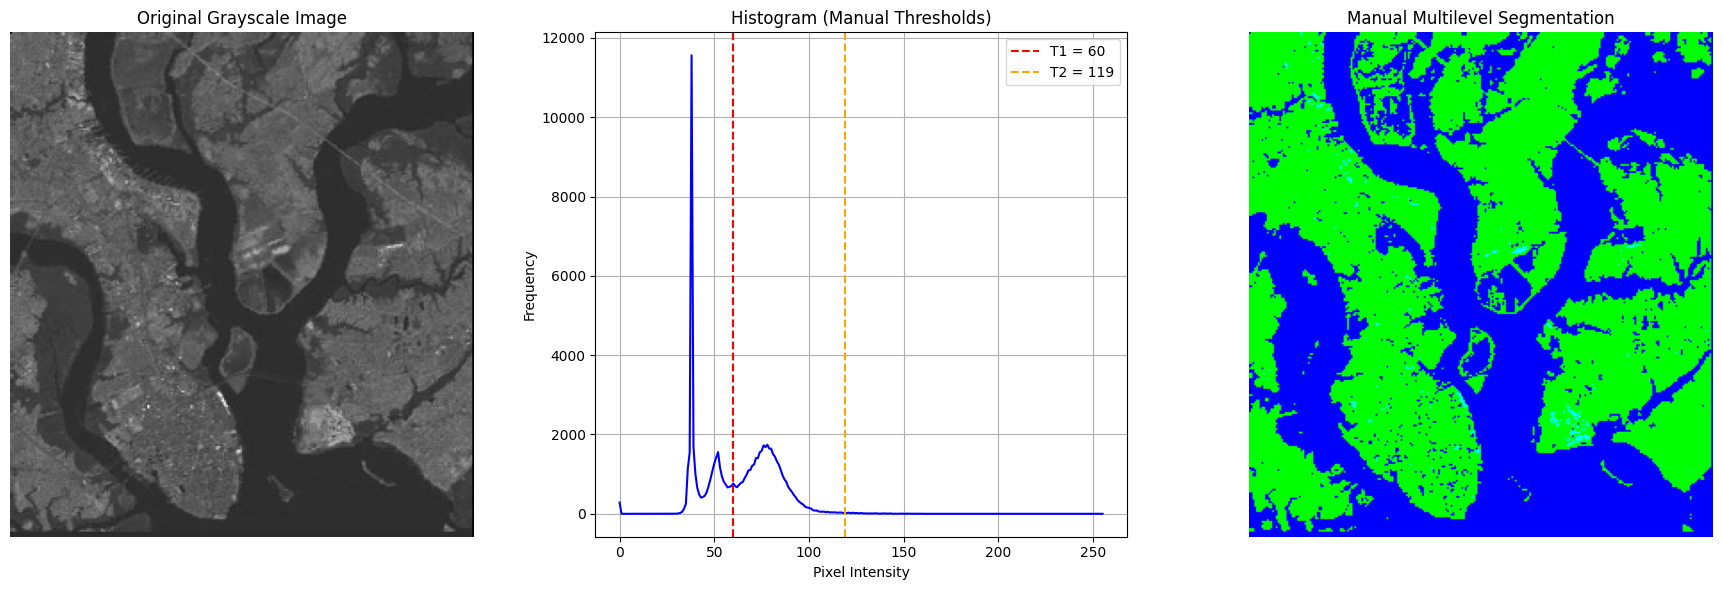

In [5]:
plt.figure(figsize=(18, 6))

# Original Grayscale Image
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

# Histogram with Manual Thresholds
plt.subplot(1, 3, 2)
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
plt.plot(hist, color='blue')
plt.axvline(x=T1_manual, color='red', linestyle='--', label=f'T1 = {T1_manual}')
plt.axvline(x=T2_manual, color='orange', linestyle='--', label=f'T2 = {T2_manual}')
plt.title("Histogram (Manual Thresholds)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

# Manual Segmentation Output
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(segmented_manual, cv2.COLOR_BGR2RGB))
plt.title("Manual Multilevel Segmentation")
plt.axis('off')

plt.tight_layout()
plt.show()

STEP 6: Visualization - Automatic Thresholding

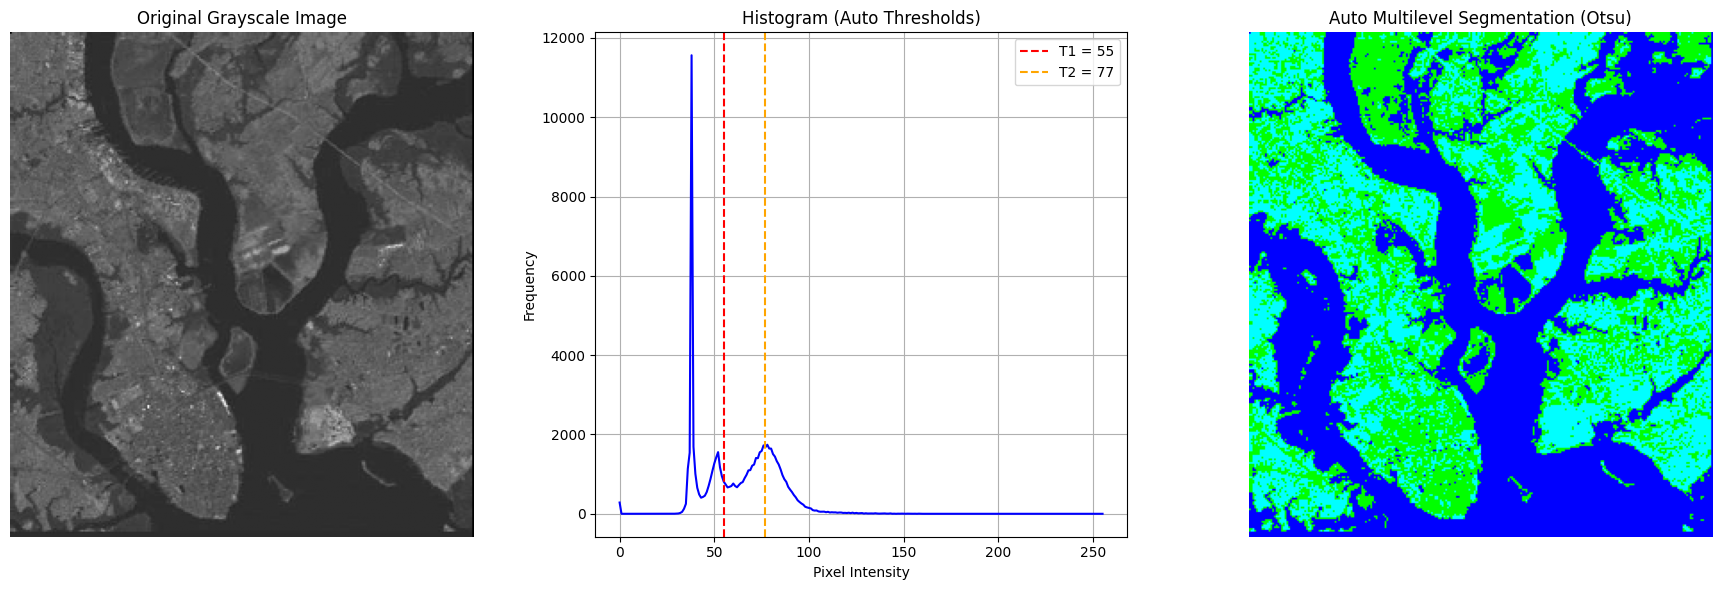

In [6]:
plt.figure(figsize=(18, 6))

# Original Image Again
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

# Histogram with Automatic Thresholds
plt.subplot(1, 3, 2)
plt.plot(hist, color='blue')  # Reuse the previously computed histogram
plt.axvline(x=T1_auto, color='red', linestyle='--', label=f'T1 = {T1_auto}')
plt.axvline(x=T2_auto, color='orange', linestyle='--', label=f'T2 = {T2_auto}')
plt.title("Histogram (Auto Thresholds)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

# Automatic Segmentation Output
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(segmented_auto, cv2.COLOR_BGR2RGB))
plt.title("Auto Multilevel Segmentation (Otsu)")
plt.axis('off')

plt.tight_layout()
plt.show()